In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot(title, label, x, result, expected):
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))

In [2]:
""" Core methods """

# Until Codon Jupyter is fixed: Read the data from files
show_plots = False

dump_folder = "dump"
dump_files = [
    "decor_trig",
    "decor",
    "fourier",
    "cheby",
    "taylor"
    ]
nbit_fs = [32, 64]
intervals_count = 2
cps = [0, 1]
exclude = []

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'Runtime': [],
    'Partitions count': [],
    'Truncations count': []
    }

for cp in cps:
    df_data[f'Bytes sent CP{cp}'] = []
    df_data[f'Requests sent CP{cp}'] = []

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for i in range(intervals_count):
            for cp in cps:
                try:
                    with open(f"{dump_folder}/{dump_file}_{i}_{nbit_f}_CP{cp}.p", "rb") as f:
                        data = pickle.load(f)
                        x = data['x']
                        interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
                        for k, v in data.items():
                            if not k.endswith('_result'):
                                continue

                            skip = False
                            for exclude_item in exclude:
                                if exclude_item in k:
                                    skip = True
                                    break
                            
                            if skip:
                                continue

                            k = k.replace('_result', '')
                            expected = data[f"{k}_expected"]

                            runtime = round(data[f"{k}_time"][0], 5)
                            bytes_sent = int(data[f"{k}_bytes_sent"][0])
                            send_requests = int(data[f"{k}_send_requests"][0])
                            partitions_count = int(data[f"{k}_partitions_count"][0])
                            truncations_count = int(data[f"{k}_truncations_count"][0])
                            
                            if cp == 1:
                                df_data['Method'].append(f"{k}_{nbit_f}")
                                df_data['Interval'].append(interval)
                                df_data['MAE'].append(mae(v, expected))
                                
                                df_data['Runtime'].append(runtime)
                                df_data['Partitions count'].append(partitions_count)
                                df_data['Truncations count'].append(truncations_count)

                            df_data[f'Bytes sent CP{cp}'].append(bytes_sent)
                            df_data[f'Requests sent CP{cp}'].append(send_requests)
                            
                            if show_plots and cp == 1:
                                plot(f"{k} {nbit_f} frac bits on {interval}", k, x, v, expected)
                except FileNotFoundError:
                    print(f"Could not find {dump_folder}/{dump_file}_{i}_{nbit_f}.p")

df = pd.DataFrame(df_data)

In [3]:
def by_interval(df):
    for interval, group in df.groupby('Interval'):
        display(group)

In [4]:
by_interval(df[df['Method'].str.contains('sin')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
7,decor_sin_64,"(-10.0, 10.0)",4.813511e-16,0.00413,2,1,12864,8,6432,4
3,decor_sin_32,"(-10.0, 10.0)",5.450308e-10,0.00124,2,1,96064,8,48032,4
110,chebyshev_17_sin_naive_64,"(-10.0, 10.0)",6.092518e-05,0.04572,17,19,176896,110,115784,72
116,chebyshev_17_sin_clenshaw_64,"(-10.0, 10.0)",6.092518e-05,0.04231,17,19,176880,110,115776,72
111,chebyshev_17_sin_decor_64,"(-10.0, 10.0)",7.888817e-05,0.01468,28,4,120672,54,66320,66
35,fourier_10_sin_32,"(-10.0, 10.0)",3.657024e-02,0.01947,2,1,960384,8,264112,4
48,fourier_10_sin_64,"(-10.0, 10.0)",4.125075e-02,0.00260,2,1,128384,8,35312,4
74,chebyshev_10_sin_naive_32,"(-10.0, 10.0)",1.804634e-01,0.00809,10,12,816560,68,528360,44
83,chebyshev_10_sin_clenshaw_32,"(-10.0, 10.0)",1.804634e-01,0.01039,10,12,816544,68,528352,44
145,taylor_6_sin_decor_32,"(-10.0, 10.0)",1.026147e+02,0.02619,24,3,520504,46,336608,56


,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
37,fourier_10_sin_64,"(3.14, 9.42)",2.351188e-16,0.00301,2,1,12896,8,6440,4
5,decor_sin_64,"(3.14, 9.42)",3.220000e-16,0.00242,2,1,12864,8,6432,4
97,chebyshev_17_sin_clenshaw_64,"(3.14, 9.42)",5.219050e-14,0.04963,17,19,176880,110,115776,72
86,chebyshev_17_sin_naive_64,"(3.14, 9.42)",5.219099e-14,0.04827,17,19,176896,110,115784,72
87,chebyshev_17_sin_decor_64,"(3.14, 9.42)",5.261745e-13,0.01625,28,4,120672,54,66320,66
24,fourier_10_sin_32,"(3.14, 9.42)",5.346768e-10,0.00811,2,1,96096,8,48040,4
1,decor_sin_32,"(3.14, 9.42)",5.373644e-10,0.00160,2,1,96064,8,48032,4
63,chebyshev_10_sin_naive_32,"(3.14, 9.42)",3.761921e-06,0.00975,10,12,816560,68,528360,44
60,chebyshev_10_sin_clenshaw_32,"(3.14, 9.42)",3.761961e-06,0.01015,10,12,816544,68,528352,44
73,chebyshev_10_sin_decor_32,"(3.14, 9.42)",3.762360e-06,0.05167,24,4,664568,50,360624,58


In [5]:
by_interval(df[df['Method'].str.contains('cos')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
6,decor_cos_64,"(-10.0, 10.0)",4.864165e-16,0.00216,2,1,12864,8,6432,4
2,decor_cos_32,"(-10.0, 10.0)",5.092248e-10,0.00239,2,1,96064,8,48032,4
112,chebyshev_17_cos_naive_64,"(-10.0, 10.0)",2.064828e-04,0.04758,17,19,176896,110,115784,72
109,chebyshev_17_cos_clenshaw_64,"(-10.0, 10.0)",2.064828e-04,0.04345,17,19,176880,110,115776,72
122,chebyshev_17_cos_decor_64,"(-10.0, 10.0)",2.066441e-04,0.01569,28,4,120672,54,66320,66
36,fourier_10_cos_32,"(-10.0, 10.0)",8.576582e-03,0.01908,1,1,960384,8,240096,2
49,fourier_10_cos_64,"(-10.0, 10.0)",9.727219e-03,0.00284,1,1,128384,8,32096,2
81,chebyshev_10_cos_naive_32,"(-10.0, 10.0)",9.699142e-02,0.00883,10,12,816560,68,528360,44
76,chebyshev_10_cos_clenshaw_32,"(-10.0, 10.0)",9.699143e-02,0.00932,10,12,816544,68,528352,44
139,taylor_6_cos_decor_32,"(-10.0, 10.0)",1.315831e+02,0.02682,24,3,520504,46,336608,56


,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
38,fourier_10_cos_64,"(3.14, 9.42)",2.793599e-16,0.00119,1,1,12896,8,3224,2
4,decor_cos_64,"(3.14, 9.42)",3.311587e-16,0.00241,2,1,12864,8,6432,4
88,chebyshev_17_cos_naive_64,"(3.14, 9.42)",6.042483e-13,0.04636,17,19,176896,110,115784,72
85,chebyshev_17_cos_clenshaw_64,"(3.14, 9.42)",6.042575e-13,0.04952,17,19,176880,110,115776,72
107,chebyshev_17_cos_decor_64,"(3.14, 9.42)",1.138420e-12,0.01523,28,4,120672,54,66320,66
0,decor_cos_32,"(3.14, 9.42)",5.347605e-10,0.00116,2,1,96064,8,48032,4
25,fourier_10_cos_32,"(3.14, 9.42)",5.365443e-10,0.00315,1,1,96096,8,24024,2
64,chebyshev_10_cos_clenshaw_32,"(3.14, 9.42)",5.035934e-07,0.00911,10,12,816544,68,528352,44
68,chebyshev_10_cos_naive_32,"(3.14, 9.42)",5.036724e-07,0.00919,10,12,816560,68,528360,44
62,chebyshev_10_cos_decor_32,"(3.14, 9.42)",5.037873e-07,0.05109,24,4,664568,50,360624,58


In [6]:
by_interval(df[df['Method'].str.contains('exp')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
21,decor_exp_64,"(-10.0, 10.0)",2.213745e-12,0.00905,28,3,59696,50,63104,64
13,decor_exp_32,"(-10.0, 10.0)",2.128018e-03,0.01301,24,3,376448,46,336608,56
117,chebyshev_17_exp_decor_64,"(-10.0, 10.0)",2.646713e-03,0.01560,28,4,120672,54,66320,66
119,chebyshev_17_exp_clenshaw_64,"(-10.0, 10.0)",2.669678e-03,0.04664,17,19,176880,110,115776,72
121,chebyshev_17_exp_naive_64,"(-10.0, 10.0)",2.669678e-03,0.04486,17,19,176896,110,115784,72
77,chebyshev_10_exp_clenshaw_32,"(-10.0, 10.0)",9.939160e+00,0.00991,10,12,816544,68,528352,44
75,chebyshev_10_exp_naive_32,"(-10.0, 10.0)",9.939160e+00,0.00937,10,12,816560,68,528360,44
33,fourier_10_exp_32,"(-10.0, 10.0)",6.744165e+02,0.01774,1,1,960384,8,240096,2
46,fourier_10_exp_64,"(-10.0, 10.0)",7.777426e+02,0.00186,1,1,128384,8,32096,2
140,taylor_6_exp_naive_32,"(-10.0, 10.0)",9.247905e+02,0.00514,6,7,480336,40,312216,26


,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
17,decor_exp_64,"(3.14, 9.42)",8.900969e-13,0.01103,28,3,59696,50,63104,64
103,chebyshev_17_exp_clenshaw_64,"(3.14, 9.42)",4.111823e-10,0.04593,17,19,176880,110,115776,72
105,chebyshev_17_exp_naive_64,"(3.14, 9.42)",4.111935e-10,0.04495,17,19,176896,110,115784,72
99,chebyshev_17_exp_decor_64,"(3.14, 9.42)",6.351254e-10,0.01519,28,4,120672,54,66320,66
9,decor_exp_32,"(3.14, 9.42)",8.816225e-06,0.01429,24,3,376448,46,336608,56
65,chebyshev_10_exp_clenshaw_32,"(3.14, 9.42)",2.975940e-03,0.00985,10,12,816544,68,528352,44
53,chebyshev_10_exp_naive_32,"(3.14, 9.42)",2.975975e-03,0.00951,10,12,816560,68,528360,44
50,chebyshev_10_exp_decor_32,"(3.14, 9.42)",2.976498e-03,0.05089,24,4,664568,50,360624,58
131,taylor_6_exp_naive_32,"(3.14, 9.42)",4.518412e+01,0.00648,6,7,480336,40,312216,26
133,taylor_6_exp_decor_32,"(3.14, 9.42)",4.518413e+01,0.03096,24,3,520504,46,336608,56


In [7]:
by_interval(df[df['Method'].str.contains('sigmoid')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
20,decor_sigmoid_64,"(-10.0, 10.0)",1.283825e-10,0.08432,212,25,443088,374,492064,484
12,decor_sigmoid_32,"(-10.0, 10.0)",6.218577e-04,0.06109,186,25,2794848,346,2739616,432
114,chebyshev_17_sigmoid_clenshaw_64,"(-10.0, 10.0)",1.183373e-03,0.04619,17,19,176880,110,115776,72
113,chebyshev_17_sigmoid_naive_64,"(-10.0, 10.0)",1.183373e-03,0.04613,17,19,176896,110,115784,72
120,chebyshev_17_sigmoid_decor_64,"(-10.0, 10.0)",1.224304e-03,0.01702,28,4,120672,54,66320,66
78,chebyshev_10_sigmoid_clenshaw_32,"(-10.0, 10.0)",1.076086e-02,0.01069,10,12,816544,68,528352,44
79,chebyshev_10_sigmoid_naive_32,"(-10.0, 10.0)",1.076086e-02,0.00954,10,12,816560,68,528360,44
34,fourier_10_sigmoid_32,"(-10.0, 10.0)",3.157696e-02,0.01796,1,1,960384,8,240096,2
47,fourier_10_sigmoid_64,"(-10.0, 10.0)",3.601856e-02,0.00231,1,1,128384,8,32096,2
146,taylor_6_sigmoid_decor_32,"(-10.0, 10.0)",2.950585e+00,0.01976,24,3,448480,46,336608,56


,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
104,chebyshev_17_sigmoid_decor_64,"(3.14, 9.42)",1.203461e-12,0.01422,28,4,120672,54,66320,66
95,chebyshev_17_sigmoid_clenshaw_64,"(3.14, 9.42)",1.219788e-12,0.04541,17,19,176880,110,115776,72
89,chebyshev_17_sigmoid_naive_64,"(3.14, 9.42)",1.219793e-12,0.04356,17,19,176896,110,115784,72
16,decor_sigmoid_64,"(3.14, 9.42)",2.286132e-11,0.08667,212,25,443088,374,492064,484
8,decor_sigmoid_32,"(3.14, 9.42)",2.608086e-10,0.05598,186,25,2794848,346,2739616,432
58,chebyshev_10_sigmoid_clenshaw_32,"(3.14, 9.42)",3.542307e-08,0.00831,10,12,816544,68,528352,44
57,chebyshev_10_sigmoid_naive_32,"(3.14, 9.42)",3.544984e-08,0.00960,10,12,816560,68,528360,44
72,chebyshev_10_sigmoid_decor_32,"(3.14, 9.42)",3.663404e-08,0.04979,24,4,664568,50,360624,58
28,fourier_10_sigmoid_32,"(3.14, 9.42)",1.301946e-03,0.01894,1,1,960384,8,240096,2
41,fourier_10_sigmoid_64,"(3.14, 9.42)",1.486459e-03,0.00255,1,1,128384,8,32096,2


In [8]:
by_interval(df[df['Method'].str.contains('sqrt')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
98,chebyshev_17_sqrt_naive_64,"(3.14, 9.42)",5.612222e-13,0.04455,17,19,176896,110,115784,72
101,chebyshev_17_sqrt_clenshaw_64,"(3.14, 9.42)",5.612222e-13,0.04243,17,19,176880,110,115776,72
106,chebyshev_17_sqrt_decor_64,"(3.14, 9.42)",5.873457e-13,0.01518,28,4,120672,54,66320,66
55,chebyshev_10_sqrt_clenshaw_32,"(3.14, 9.42)",1.173215e-08,0.01008,10,12,816544,68,528352,44
54,chebyshev_10_sqrt_naive_32,"(3.14, 9.42)",1.175542e-08,0.00849,10,12,816560,68,528360,44
52,chebyshev_10_sqrt_decor_32,"(3.14, 9.42)",1.793178e-08,0.05039,24,4,664568,50,360624,58
136,taylor_6_sqrt_decor_32,"(3.14, 9.42)",2.230461e-02,0.03767,24,3,520504,46,336608,56
126,taylor_6_sqrt_naive_32,"(3.14, 9.42)",2.230470e-02,0.00617,6,7,480336,40,312216,26
152,taylor_6_sqrt_naive_64,"(3.14, 9.42)",2.273763e-02,0.01499,6,7,64336,40,41816,26
162,taylor_6_sqrt_decor_64,"(3.14, 9.42)",2.273763e-02,0.01138,28,3,78952,50,63104,64


In [9]:
by_interval(df[df['Method'].str.contains('mul_inv')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
90,chebyshev_17_mul_inv_naive_64,"(3.14, 9.42)",1.155808e-11,0.04553,17,19,176896,110,115784,72
94,chebyshev_17_mul_inv_clenshaw_64,"(3.14, 9.42)",1.155808e-11,0.04341,17,19,176880,110,115776,72
93,chebyshev_17_mul_inv_decor_64,"(3.14, 9.42)",1.162669e-11,0.01587,28,4,120672,54,66320,66
51,chebyshev_10_mul_inv_clenshaw_32,"(3.14, 9.42)",1.136695e-07,0.00999,10,12,816544,68,528352,44
61,chebyshev_10_mul_inv_naive_32,"(3.14, 9.42)",1.137168e-07,0.00988,10,12,816560,68,528360,44
67,chebyshev_10_mul_inv_decor_32,"(3.14, 9.42)",1.153603e-07,0.05112,24,4,664568,50,360624,58
128,taylor_6_mul_inv_naive_32,"(3.14, 9.42)",1.962335e-04,0.00548,6,7,480336,40,312216,26
125,taylor_6_mul_inv_decor_32,"(3.14, 9.42)",1.966806e-04,0.03345,24,3,520504,46,336608,56
151,taylor_6_mul_inv_decor_64,"(3.14, 9.42)",2.098230e-04,0.01097,28,3,78952,50,63104,64
154,taylor_6_mul_inv_naive_64,"(3.14, 9.42)",2.098230e-04,0.01475,6,7,64336,40,41816,26


In [10]:
by_interval(df[df['Method'].str.contains('log')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
91,chebyshev_17_log_naive_64,"(3.14, 9.42)",3.511522e-12,0.04964,17,19,176896,110,115784,72
92,chebyshev_17_log_clenshaw_64,"(3.14, 9.42)",3.511524e-12,0.04233,17,19,176880,110,115776,72
100,chebyshev_17_log_decor_64,"(3.14, 9.42)",3.571958e-12,0.01466,28,4,120672,54,66320,66
70,chebyshev_10_log_clenshaw_32,"(3.14, 9.42)",5.669820e-08,0.00850,10,12,816544,68,528352,44
56,chebyshev_10_log_naive_32,"(3.14, 9.42)",5.669985e-08,0.01005,10,12,816560,68,528360,44
69,chebyshev_10_log_decor_32,"(3.14, 9.42)",5.956122e-08,0.05011,24,4,664568,50,360624,58
130,taylor_6_log_naive_32,"(3.14, 9.42)",1.669719e-04,0.00590,6,7,480336,40,312216,26
132,taylor_6_log_decor_32,"(3.14, 9.42)",1.670335e-04,0.02914,24,3,520504,46,336608,56
158,taylor_6_log_decor_64,"(3.14, 9.42)",1.783266e-04,0.01189,28,3,78952,50,63104,64
156,taylor_6_log_naive_64,"(3.14, 9.42)",1.783266e-04,0.01589,6,7,64336,40,41816,26


In [11]:
by_interval(df[df['Method'].str.contains('tanh')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
108,chebyshev_17_tanh_clenshaw_64,"(-10.0, 10.0)",2.815440e-02,0.04364,17,19,176880,110,115776,72
115,chebyshev_17_tanh_naive_64,"(-10.0, 10.0)",2.815440e-02,0.04469,17,19,176896,110,115784,72
118,chebyshev_17_tanh_decor_64,"(-10.0, 10.0)",2.895572e-02,0.01589,28,4,120672,54,66320,66
32,fourier_10_tanh_32,"(-10.0, 10.0)",6.426757e-02,0.01849,1,1,960384,8,240096,2
80,chebyshev_10_tanh_naive_32,"(-10.0, 10.0)",6.695843e-02,0.00919,10,12,816560,68,528360,44
82,chebyshev_10_tanh_clenshaw_32,"(-10.0, 10.0)",6.695843e-02,0.00930,10,12,816544,68,528352,44
22,decor_tanh_64,"(-10.0, 10.0)",7.029120e-02,0.08367,212,25,443088,374,492064,484
45,fourier_10_tanh_64,"(-10.0, 10.0)",7.310941e-02,0.00297,1,1,128384,8,32096,2
144,taylor_6_tanh_decor_32,"(-10.0, 10.0)",7.950940e+01,0.01878,24,3,448480,46,336608,56
143,taylor_6_tanh_naive_32,"(-10.0, 10.0)",7.950940e+01,0.00384,3,4,264192,22,168120,14


,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
102,chebyshev_17_tanh_decor_64,"(3.14, 9.42)",5.407320e-12,0.01506,28,4,120672,54,66320,66
96,chebyshev_17_tanh_naive_64,"(3.14, 9.42)",5.456764e-12,0.04688,17,19,176896,110,115784,72
84,chebyshev_17_tanh_clenshaw_64,"(3.14, 9.42)",5.456768e-12,0.04501,17,19,176880,110,115776,72
71,chebyshev_10_tanh_clenshaw_32,"(3.14, 9.42)",1.318070e-07,0.00931,10,12,816544,68,528352,44
59,chebyshev_10_tanh_naive_32,"(3.14, 9.42)",1.318356e-07,0.00948,10,12,816560,68,528360,44
66,chebyshev_10_tanh_decor_32,"(3.14, 9.42)",1.326279e-07,0.05142,24,4,664568,50,360624,58
31,fourier_10_tanh_32,"(3.14, 9.42)",1.162663e-04,0.01861,1,1,960384,8,240096,2
44,fourier_10_tanh_64,"(3.14, 9.42)",1.332866e-04,0.00230,1,1,128384,8,32096,2
134,taylor_6_tanh_naive_32,"(3.14, 9.42)",1.825843e-02,0.00385,3,4,264192,22,168120,14
135,taylor_6_tanh_decor_32,"(3.14, 9.42)",1.825843e-02,0.01914,24,3,448480,46,336608,56


In [12]:
by_interval(df[df['Method'].str.contains('polynomial')].sort_values(by='MAE'))

,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
23,decor_polynomial_64,"(-10.0, 10.0)",1.781527e-12,0.00957,28,3,69328,50,63104,64
15,decor_polynomial_32,"(-10.0, 10.0)",1.578820e-05,0.01987,24,3,448480,46,336608,56


,Method,Interval,MAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
19,decor_polynomial_64,"(3.14, 9.42)",3.254286e-13,0.01064,28,3,69328,50,63104,64
11,decor_polynomial_32,"(3.14, 9.42)",1.925266e-06,0.01893,24,3,448480,46,336608,56


In [13]:
""" E2E apps """

# Until Codon Jupyter is fixed: Read the data from files
dump_folder = "dump"
dump_files = [
    "log_reg",
    "dti"
    ]
nbit_fs = [32]

df_data = {
    'Method': [],
    'Accuracy': [],
    'Runtime': [],
    'Bytes sent': [],
    'Requests sent': [],
    'Partitions count': [],
    'Truncations count': []
    }

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        try:
            with open(f"{dump_folder}/{dump_file}_{nbit_f}.p", "rb") as f:
                data = pickle.load(f)
                for k, v in data.items():
                    if not k.endswith('_accuracy'):
                        continue
                    
                    k = k.replace('_accuracy', '')
                    accuracy = data[f"{k}_accuracy"][0]
                    runtime = round(data[f"{k}_time"][0], 5)
                    bytes_sent = int(data[f"{k}_bytes_sent"][0])
                    send_requests = int(data[f"{k}_send_requests"][0])
                    partitions_count = int(data[f"{k}_partitions_count"][0])
                    truncations_count = int(data[f"{k}_truncations_count"][0])
                    
                    df_data['Method'].append(f"{k}_{nbit_f}")
                    
                    df_data['Accuracy'].append(accuracy)
                    df_data['Runtime'].append(runtime)
                    df_data['Bytes sent'].append(bytes_sent)
                    df_data['Requests sent'].append(send_requests)
                    df_data['Partitions count'].append(partitions_count)
                    df_data['Truncations count'].append(truncations_count)
        except FileNotFoundError:
            print(f"Could not find {dump_folder}/{dump_file}_{nbit_f}.p")

e2e_df = pd.DataFrame(df_data)

In [14]:
e2e_df[e2e_df['Method'].str.contains('binary')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
4,log_reg_binary_decor_32,0.9375,0.21557,1237072,6602,1841,1440
1,log_reg_binary_chebyshev_32,0.8750,0.03795,205392,922,201,260
2,log_reg_binary_fourier_32,0.6875,0.19390,148112,282,81,80
5,log_reg_binary_taylor_32,0.5000,0.02244,117552,482,101,140


In [15]:
e2e_df[e2e_df['Method'].str.contains('multinomial')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
3,log_reg_multinomial_fourier_32,0.9375,0.56319,2458512,5122,2361,80
6,log_reg_multinomial_chebyshev_32,0.9375,0.40785,2623312,5762,2481,260
7,log_reg_multinomial_taylor_32,0.9375,0.39607,2506672,5562,2441,200
0,log_reg_multinomial_decor_32,0.7500,0.40416,2537552,6162,2801,120


In [16]:
e2e_df[e2e_df['Method'].str.contains('dti')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
15,dti_linear_chebyshev_32,0.708333,168.88176,2403710984,5646,2201,498
8,dti_tanh_chebyshev_32,0.583333,169.70991,2372641816,5876,1885,969
13,dti_sigmoid_fourier_32,0.562500,178.18849,2401271016,9124,3299,1180
9,dti_tanh_fourier_32,0.520833,173.81166,2371618536,4564,1639,600
10,dti_tanh_decor_32,0.520833,182.78921,2490082072,24736,9101,2978
11,dti_tanh_taylor_32,0.500000,173.72765,2371038256,4974,1680,723
12,dti_sigmoid_chebyshev_32,0.500000,176.92023,2402294296,10436,3545,1549
14,dti_sigmoid_taylor_32,0.500000,177.04375,2400690736,9534,3340,1303
16,dti_sigmoid_decor_32,0.479167,187.79492,2519734552,29296,10761,3558


In [17]:
import math


def by_name(name, df):
    return df[df['Method'].str.startswith(name)]

def plot_accuracy_vs_perf(
        df, methods=["sin", "cos", "exp", "sigmoid"],
        metric="Runtime", intervals_count=1,
        approaches=["decor", "chebyshev", "fourier", "taylor"],
        markers=["o", "s", "^", "v"], remove_outliers=False):
    
    _, axs = plt.subplots(2, 2, figsize=(12, 10))
    for idx, method in enumerate(methods):
        ax = axs[idx // 2, idx % 2]

        filtered_df = df[df['Method'].str.contains(method)]
        filtered_df = filtered_df[
            ~filtered_df['Method'].str.contains('_decor') &
            (~filtered_df['Method'].str.contains('_naive') |
             filtered_df['Method'].str.contains('taylor_'))
        ]
        filtered_df['Method'] = filtered_df['Method'].str.replace(f"{method}_", "", regex=False)
        
        if remove_outliers:
            filtered_df = filtered_df[filtered_df['MAE'] < 0.5]
        
        # Convert MAE to accuracy
        filtered_df['MAE'] = filtered_df['MAE'].apply(lambda x: -math.log(x))
        
        groups = list(filtered_df.groupby('Interval'))[:intervals_count]
        for interval, group in groups:
            for approach, marker in zip(approaches, markers):
                filtered_group = group[group['Method'].str.startswith(approach)]
                if filtered_group.empty:
                    continue
                ax.scatter(
                    filtered_group[metric], filtered_group["MAE"],
                    label=approach.capitalize(), marker=marker,
                    edgecolors=[
                        ('black' if m.endswith('64') else 'none') for m in filtered_group['Method']]
                )
            ax.set_title(f"{method} at {interval}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Accuracy: -log(MAE)")
            ax.grid(True)
        if idx == 1:
            ax.legend(title="Bordered: 64 bits\nNon-bordered: 32 bits", loc='upper right')
    
    plt.tight_layout()
    plt.show()

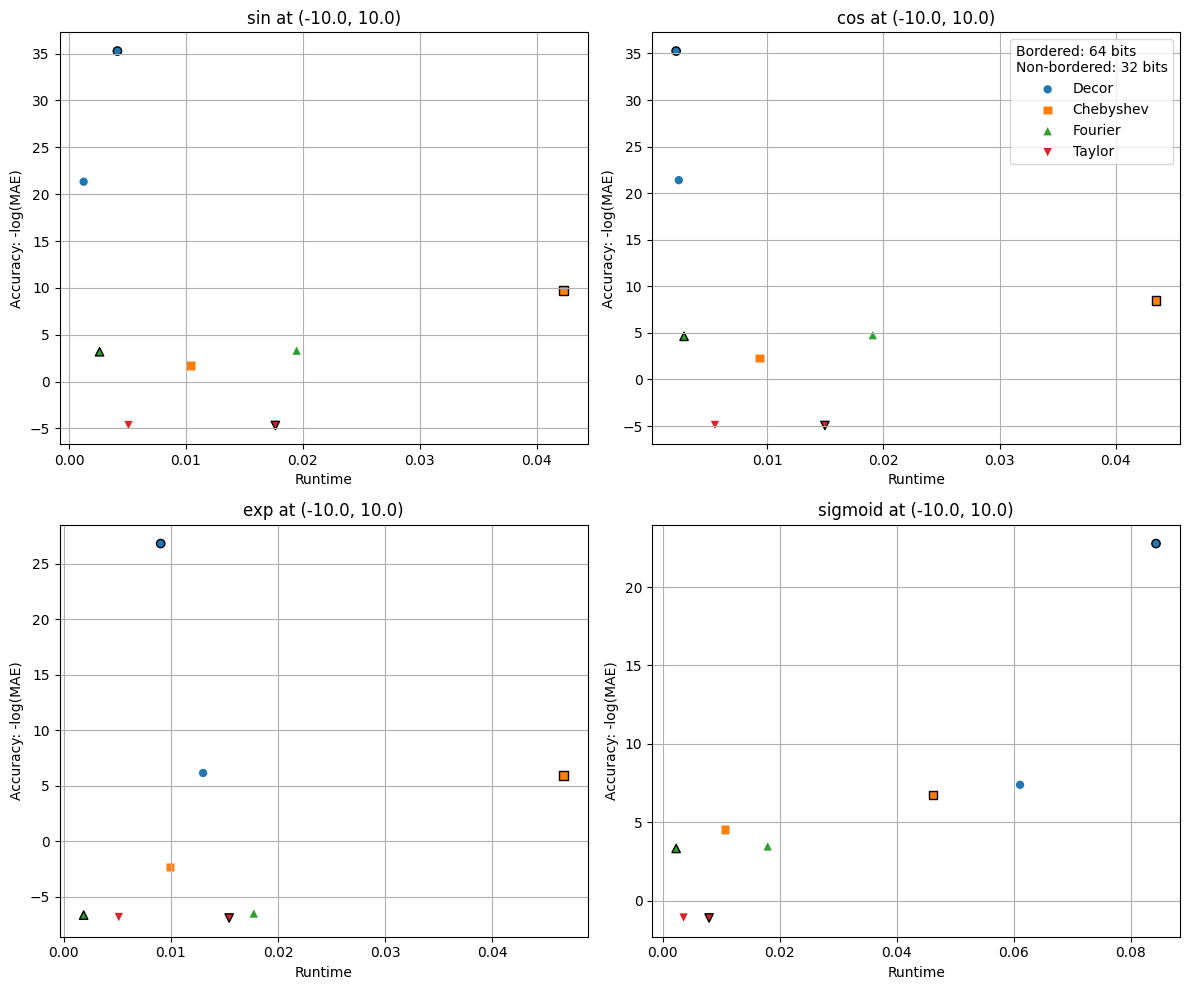

In [18]:
plot_accuracy_vs_perf(df)